# Лабораторная работа 3. Автокорреляционная функция (АКФ).

**Целью работы** является исследование свойств оценок автокорреляционной функции.

 <hr>    

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1.](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2.](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3.](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4.](#job4)</font>        

<font style="color:#1560BD;" size="5">[Задание 5.](#job5)</font>

## Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт библиотек
import matplotlib.pyplot as plt
import numpy as np
import librosa
import statsmodels.api as sm
from scipy import signal

# Игнорируем предупреждения
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "speech/"  # Сигналы для третьей лабораторной работы

<div class="alert alert-block alert-info">

## Задание 1.
<a id="job1"></a>
* Возьмите сигнал **White_noise_11025** (белый шум).

* Постройте среднюю оценку АКФ с разной длиной окна.

* Исследуйте зависимость средней АКФ от длины и типа окна (прямоугольное и др.)

* Как средняя АКФ зависит от длины и типа окна?

* Увеличьте амплитуду сигнала в 2 раза. Как средняя АКФ зависит от уровня сигнала?
</div>

In [ ]:
# Загружаем сигнал  White_noise_11025.wav
data_white_noise_11025, sr_white_noise_11025 = librosa.load(
    Speech_dir + "//White_noise_11025.wav", sr=None
)

In [ ]:
# Усредненная автокорреляционная функция (усреднение по кадрам, без перекрытия)
def AAF(data, frame_len, win, lag):
    # data - исходные данные
    # frame_len - длина кадра
    # win - окно
    # lag - число задержек
    acorrs = np.zeros(lag)

    for i in range(0, len(data) - frame_len + 1, frame_len):
        # Предварительно центрируем сигнал
        X = data[i : i + frame_len]
        mean = np.mean(X)
        X = X - mean
        acorr = sm.tsa.acf(X * win, nlags=lag)
        acorrs += acorr[0:lag]
    return acorrs / np.max(acorrs)

In [ ]:
# Временная шкала для автокорреляционной функции (в миллисекундах)
def Timeline(lag, fd):
    # lag - максимальная задержка (в отсчетах)
    # fd - частота дискретизации (Гц)
    shag = 1000.0 / fd
    lagn = (lag + 1) * shag
    return np.arange(0, lagn, shag)[0:lag]

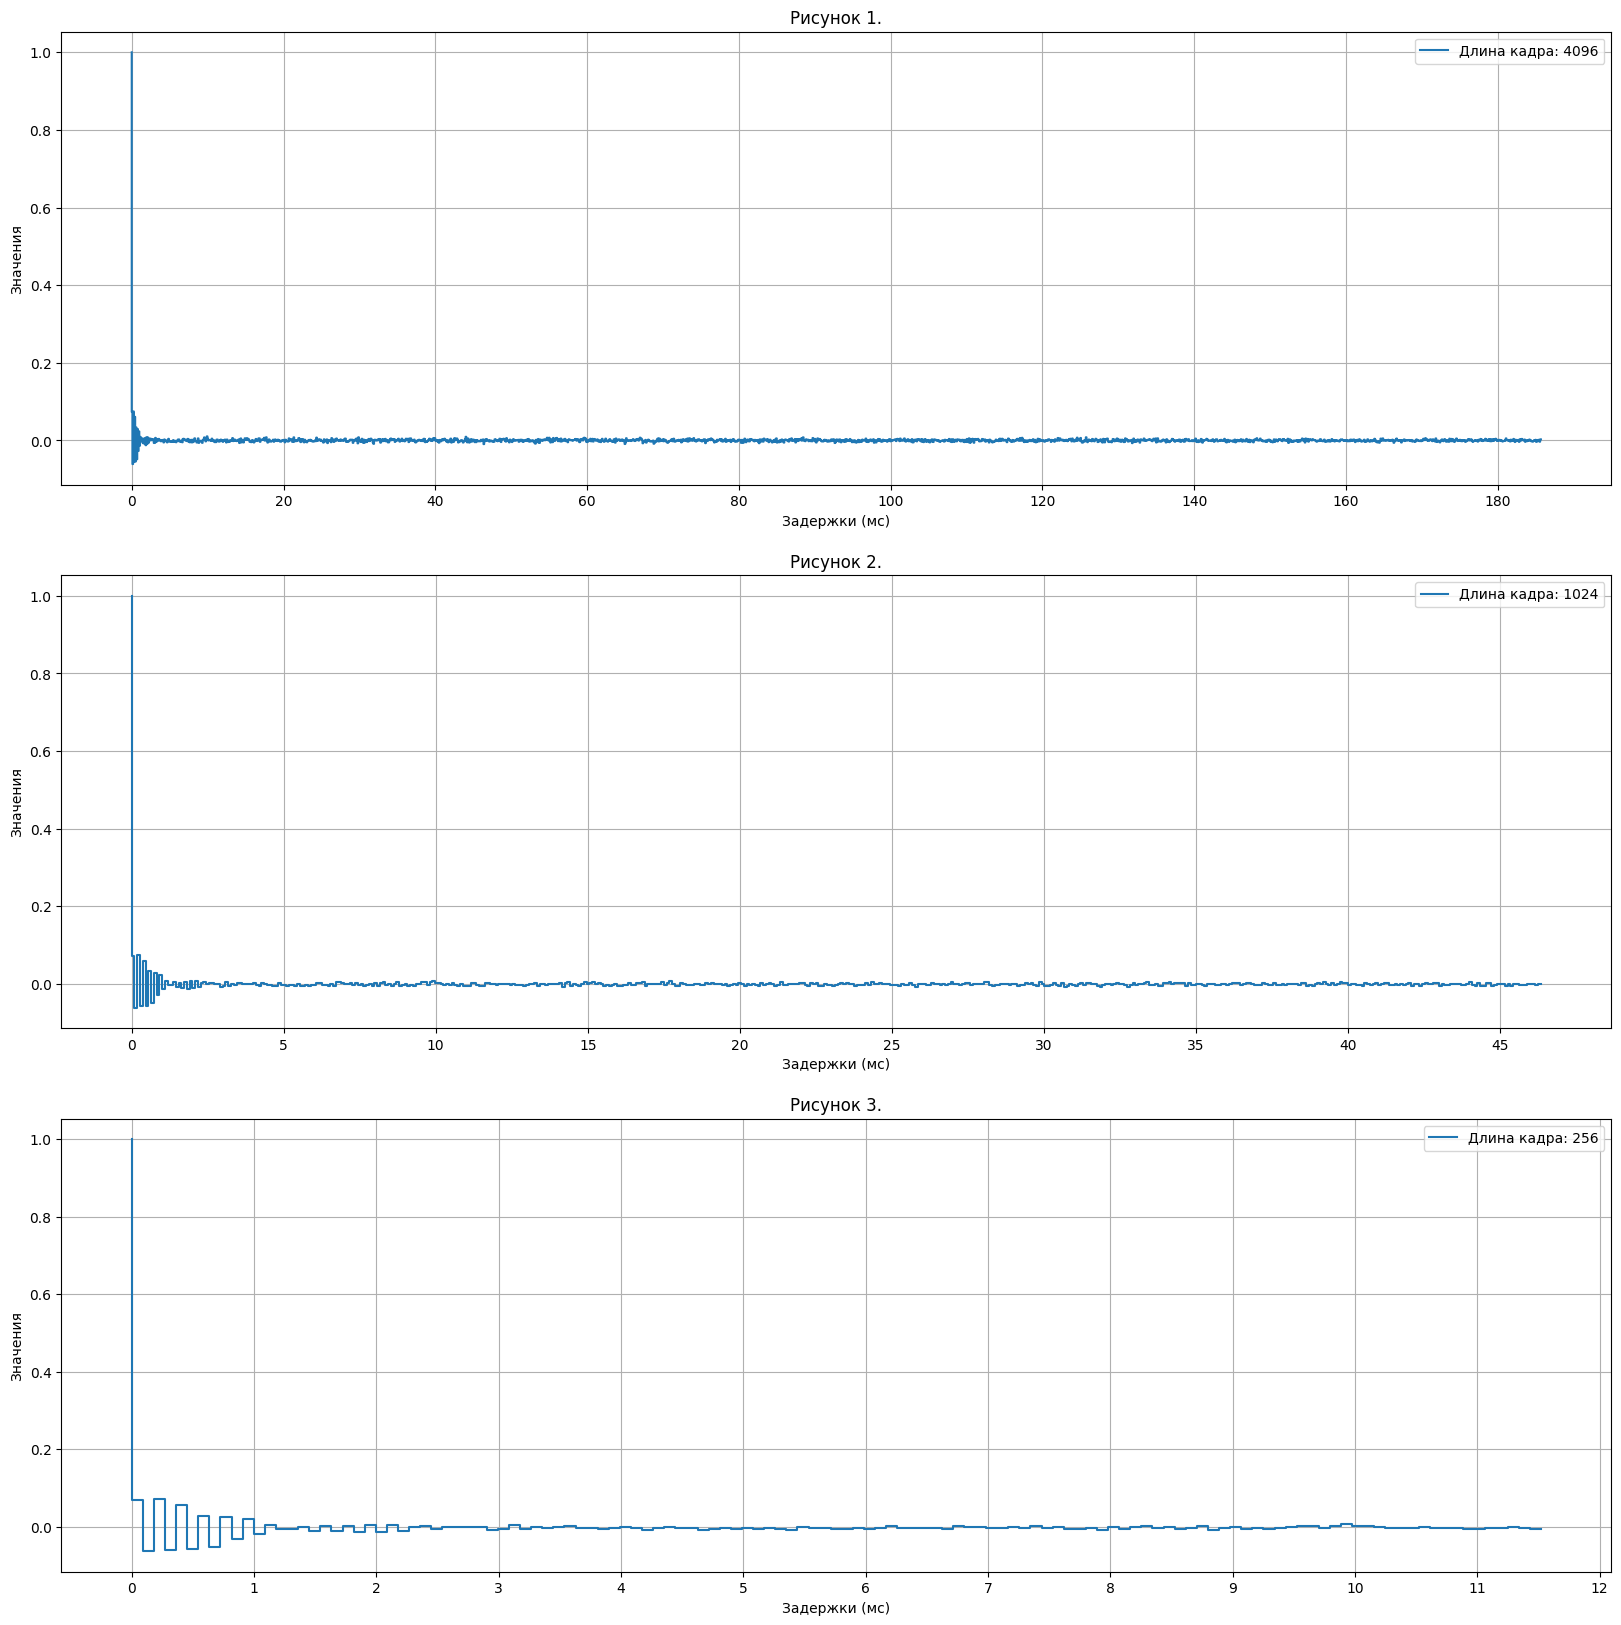

In [ ]:
# Строим средние оценки АКФ с разной длиной кадра.
frame_len = [4096, 1024, 256]

plt.figure(figsize=(20, 20))

for i in range(3):
    lags = frame_len[i] // 2
    win = signal.windows.boxcar(frame_len[i])  # Окно прямоугольное
    acf = AAF(data=data_white_noise_11025, frame_len=frame_len[i], win=win, lag=lags)

    # Строим шкалу в mc
    t = Timeline(lags, sr_white_noise_11025)
    plt.subplot(3, 1, i + 1)
    plt.step(t, acf, label="Длина кадра: {:d}".format(frame_len[i]))
    plt.title("Рисунок {:d}.".format(i + 1))
    plt.xlabel("Задержки (мс)")
    plt.ylabel("Значения")
    plt.legend(loc=1)

    plt.locator_params(axis="x", nbins=16)
    plt.grid(True)
plt.show()

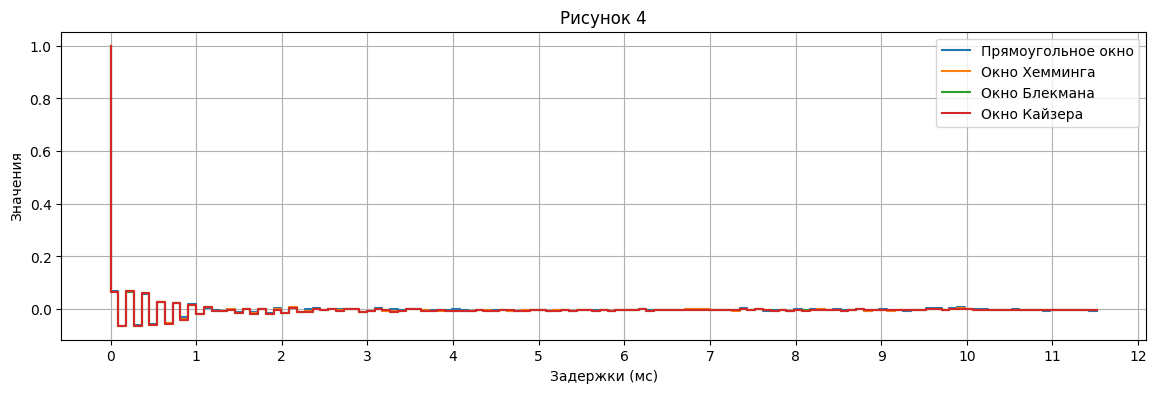

In [ ]:
# Строим шкалу в мс
frame_len = 256
lag = frame_len // 2
t = Timeline(lag, sr_white_noise_11025)

# Строим средние оценки АКФ для разных окон
win = signal.windows.boxcar(frame_len)  # Окно прямоугольное
acf_boxcar = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.hamming(frame_len)  # Окно Хемминга
acf_hamming = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.blackman(frame_len)  # Окно Блекмана
acf_blackman = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.kaiser(frame_len, beta=8)  # Окно Кайзера
acf_kaiser = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

# Визуализация
plt.figure(figsize=(14, 4))
plt.step(t, acf_boxcar, label="Прямоугольное окно")
plt.step(t, acf_hamming, label="Окно Хемминга")
plt.step(t, acf_blackman, label="Окно Блекмана")
plt.step(t, acf_kaiser, label="Окно Кайзера")
plt.title("Рисунок 4")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")
plt.legend(loc=1)
plt.locator_params(axis="x", nbins=16)
plt.grid(True)
plt.show()

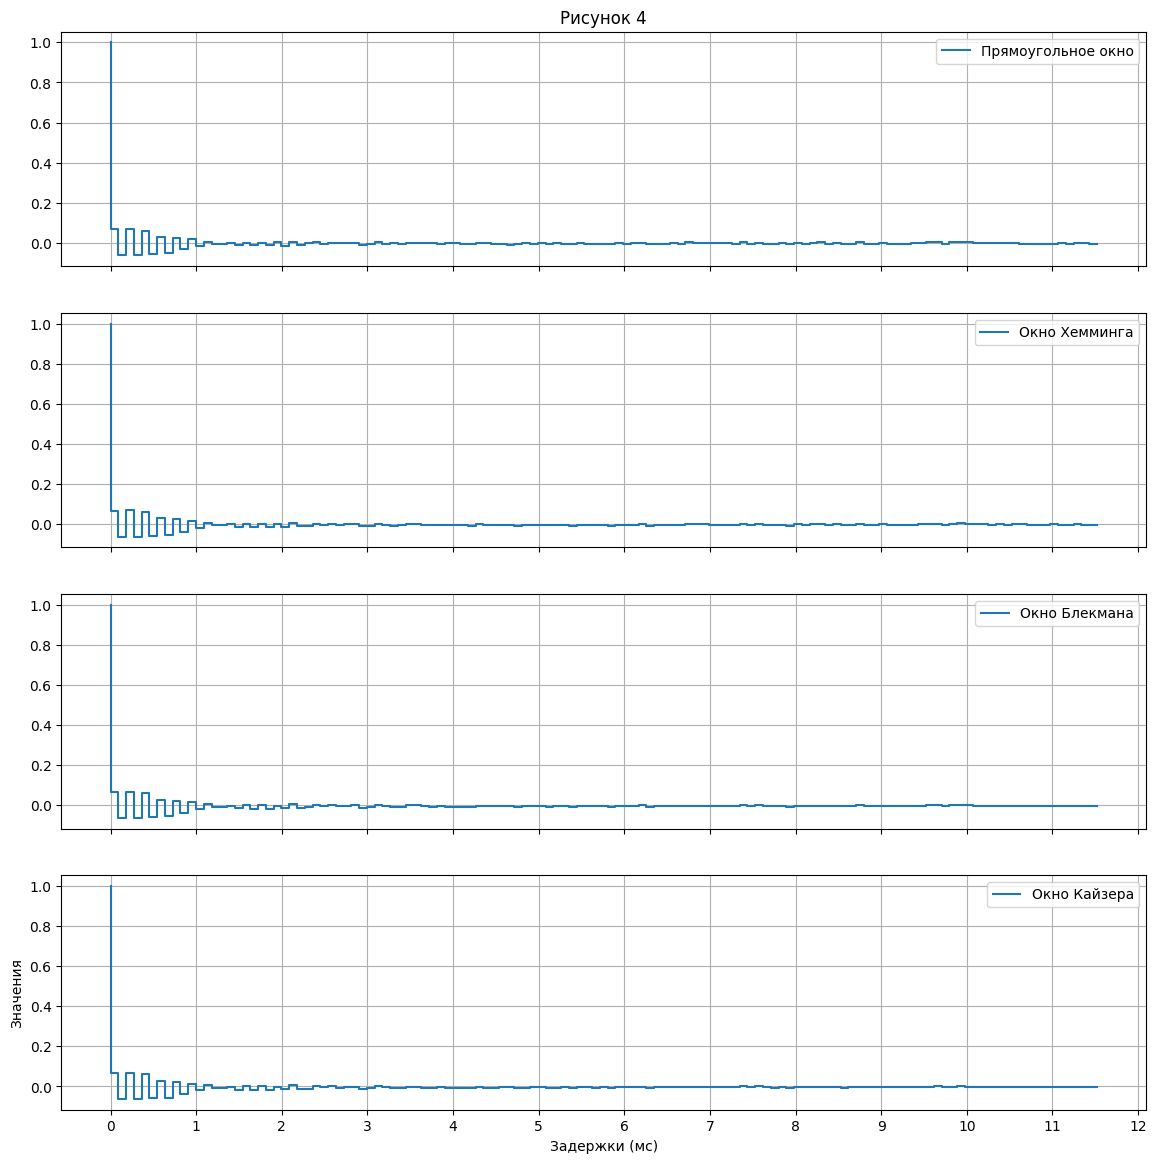

In [ ]:
# Строим шкалу в мс
frame_len = 256
lag = frame_len // 2
t = Timeline(lag, sr_white_noise_11025)

# Строим средние оценки АКФ для разных окон
win = signal.windows.boxcar(frame_len)  # Окно прямоугольное
acf_boxcar = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.hamming(frame_len)  # Окно Хемминга
acf_hamming = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.blackman(frame_len)  # Окно Блекмана
acf_blackman = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

win = signal.windows.kaiser(frame_len, beta=8)  # Окно Кайзера
acf_kaiser = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)

# Визуализация
fig, ax = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
ax[0].step(t, acf_boxcar, label="Прямоугольное окно")
ax[1].step(t, acf_hamming, label="Окно Хемминга")
ax[2].step(t, acf_blackman, label="Окно Блекмана")
ax[3].step(t, acf_kaiser, label="Окно Кайзера")
ax[0].set_title("Рисунок 4")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")
ax[0].legend(loc=1)
ax[1].legend(loc=1)
ax[2].legend(loc=1)
ax[3].legend(loc=1)
plt.locator_params(axis="x", nbins=16)
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[3].grid(True)
plt.show()

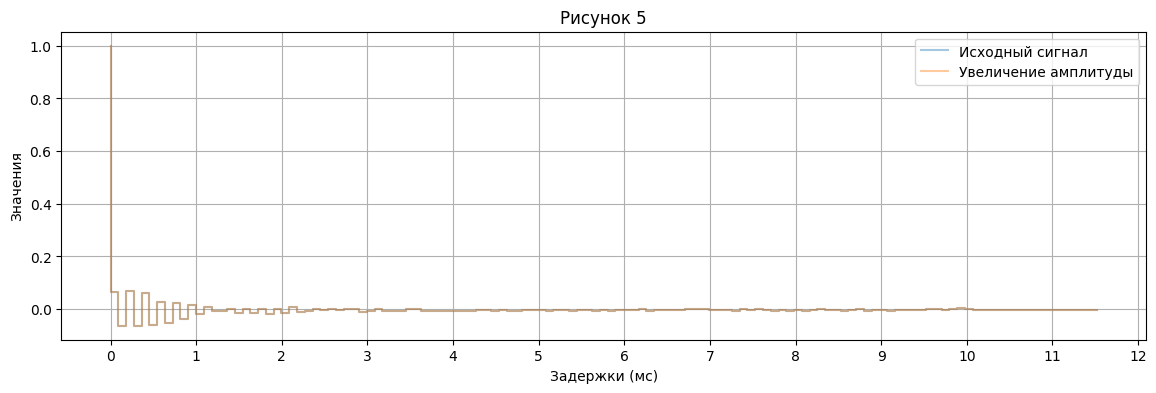

In [ ]:
# Строим шкалу в mc.
frame_len = 256
lag = frame_len // 2
t = Timeline(lag, sr_white_noise_11025)

# АКФ при увеличении сигнала (с окном Хемминга)
data_white_noise_11025_2 = data_white_noise_11025 * 2

win = signal.windows.hamming(frame_len)  # Окно Хемминга

acf = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)
acf2 = AAF(data=data_white_noise_11025_2, frame_len=frame_len, win=win, lag=lag)

# Визуализация
plt.figure(figsize=(14, 4))
plt.step(t, acf, label="Исходный сигнал", alpha=0.4)
plt.step(t, acf2, label="Увеличение амплитуды", alpha=0.4)
plt.title("Рисунок 5")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")
plt.legend(loc=1)
plt.locator_params(axis="x", nbins=16)
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>

С коротким окном АКФ как будто колеблится ближе к нулю, но, скорее всего, при слишком маленьком окне АКФ более подвержена случайным небольшим колебаниям.

По типам окон у прямоугольного больше всего задержек, но они короткие, следом по числу задержке идёт окно Кайзера, затем Хемминг и у Блэкмана меньше всего задержек.

При увеличение амлитуды в 2 раза значения АКФ остаются такими же, поскольку мы нормируем её на максимальное значение

</div>

<div class="alert alert-block alert-info">

## Задание 2.
<a id="job2"></a>

* Возьмите сигнал **White_noise_11025** (белый шум).

* Постройте среднюю оценку АКФ.

* Добавьте к сигналу константу. Как средняя АКФ зависит от величины константы?
</div>

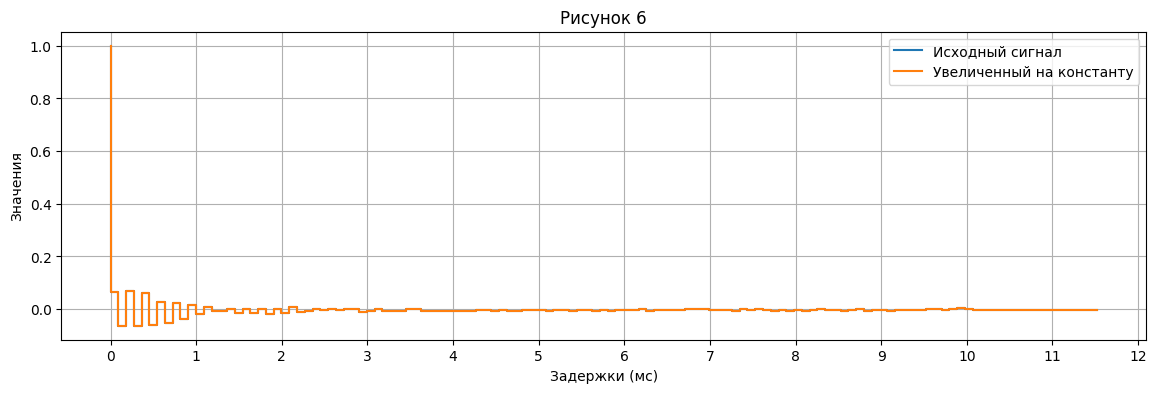

In [ ]:
# Строим шкалу в мс
frame_len = 256
lag = frame_len // 2
t = Timeline(lag, sr_white_noise_11025)

# АКФ при добавлении константы (с окном Хемминга)
data_white_noise_11025_const = data_white_noise_11025 + 0.5

win = signal.windows.hamming(frame_len)  # Окно Хемминга

acf = AAF(data=data_white_noise_11025, frame_len=frame_len, win=win, lag=lag)
acf_const = AAF(
    data=data_white_noise_11025_const, frame_len=frame_len, win=win, lag=lag
)

# Визуализация
plt.figure(figsize=(14, 4))
plt.step(t, acf, label="Исходный сигнал")
plt.step(t, acf_const, label="Увеличенный на константу")
plt.title("Рисунок 6")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")
plt.legend(loc=1)
plt.locator_params(axis="x", nbins=16)
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

Средняя АКФ не зависит от добавления константы к сигналу, поскольку мы её центрируем и, по факту, избавляемся от неё

</div>

<div class="alert alert-block alert-info">

## Задание 3.
<a id="job3"></a>

* Сгенерируйте периодический гармонический (тональный) сигнал: $F_s = 11025$ Hz, $F_0=100$ Hz.

* Постройте среднюю АКФ с разной длиной окна.

* Объясните уменьшение размаха АКФ с увеличением задержки.

* Можно ли наблюдать периодическую компоненту сигнала на средней АКФ?
</div>

In [ ]:
# Генерация тонального сигнала: основная частота, длительность(сек.), частота дискретизации (гц)
sample_rate = 100
tone = librosa.tone(sample_rate, duration=10, sr=11025)

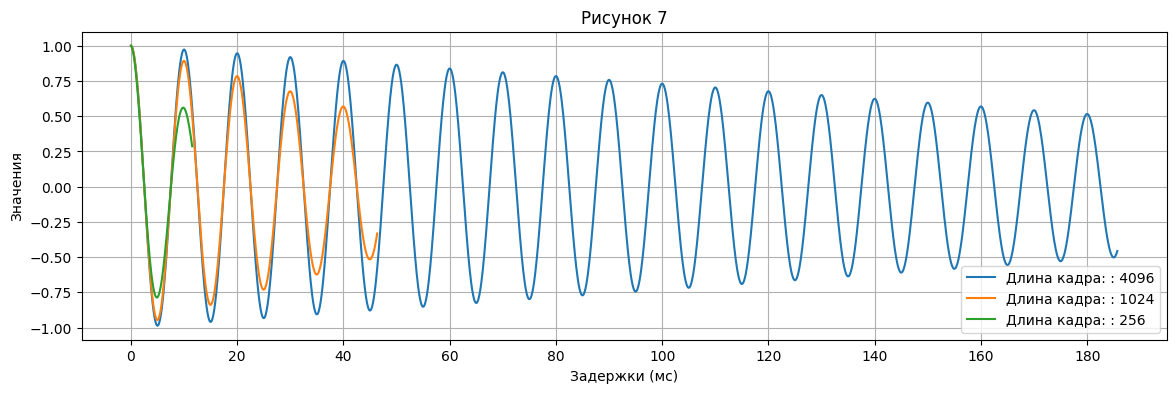

In [ ]:
# Строим средние оценки АКФ тонального сигнала с разной длиной кадра.
frame_len = [4096, 1024, 256]

plt.figure(figsize=(14, 4))
plt.title("Рисунок 7")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")

for i in range(3):
    lags = frame_len[i] // 2
    win = signal.windows.boxcar(frame_len[i])  # Окно прямоугольное
    acf = AAF(data=tone, frame_len=frame_len[i], win=win, lag=lags)
    # Строим шкалу в mc.
    t = Timeline(lags, 11025)
    plt.plot(t, acf, label="Длина кадра: : {:d}".format(frame_len[i]))

plt.legend(loc="lower right")
plt.locator_params(axis="x", nbins=16)
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

На малой задержке случайные отклонения могут быть заметнее из-за большего числа слагаемых. На большой же - число слагаемых уменьшается, и случайные отклонения сильнее усредняются, поэтому амплитуда колебаний уменьшается.

Да, ясно видно, что сигнал периодичен
</div>

<div class="alert alert-block alert-info">

## Задание 4.
<a id="job4"></a>
* Возьмите фонограмму **11_100Hz.wav** (периодический импульсный сигнал).

* Постройте среднюю АКФ.

* Объясните, какими свойствами сигнала определяется форма АКФ?
</div>

In [ ]:
# Загружаем сигнал 11_100Hz.wav
data_11_100Hz, sr_11_100Hz = librosa.load(Speech_dir + "//11_100HZ.WAV", sr=None)

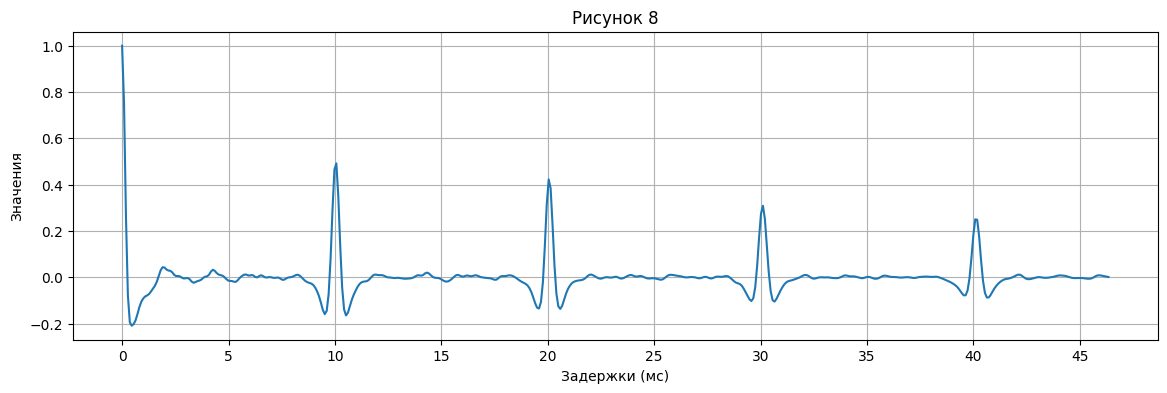

In [ ]:
# Строим шкалу в mc.
frame_len = 1024
lag = frame_len // 2
t = Timeline(lag, sr_11_100Hz)

# Строим среднюю оценку АКФ сигнала
win = signal.windows.boxcar(frame_len)  # Окно прямоугольное
acf_data_11_100Hz = AAF(data=data_11_100Hz, frame_len=frame_len, win=win, lag=lag)

# Визуализация
plt.figure(figsize=(14, 4))
plt.plot(t, acf_data_11_100Hz)
plt.title("Рисунок 8")
plt.xlabel("Задержки (мс)")
plt.ylabel("Значения")
plt.locator_params(axis="x", nbins=16)
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

Форма АКФ определяется продолжительностью сигнала и периодичностью (насколько АКФ будет вытянутым по оси X и будут ли похожие пики), формой (какого вида будут пики, поскольку они по факту получаются после операции свёртки со своими сдвинутыми копиями), амплитудой (высота пиков).
</div>

<div class="alert alert-block alert-info">

## Задание 5.
<a id="job5"></a>
* Возьмите речевой сигнал **11sp_fm1.wav**.

* Постройте среднюю АКФ речевого сигнала 11sp_fm1.wav.
                                   
* Что произойдет со средней АКФ, если мы увеличим частоту дискретизации сигнала вдвое?
</div>

In [ ]:
# Загружаем речевой сигнал 11sp_fm1.wav
data_11sp_fm1, sr_11sp_fm1 = librosa.load(Speech_dir + "//11sp_fm1.wav", sr=None)

In [ ]:
# Увеличиваем частоту
data_11sp_fm2 = librosa.resample(
    data_11sp_fm1, orig_sr=sr_11sp_fm1, target_sr=sr_11sp_fm1 * 2
)

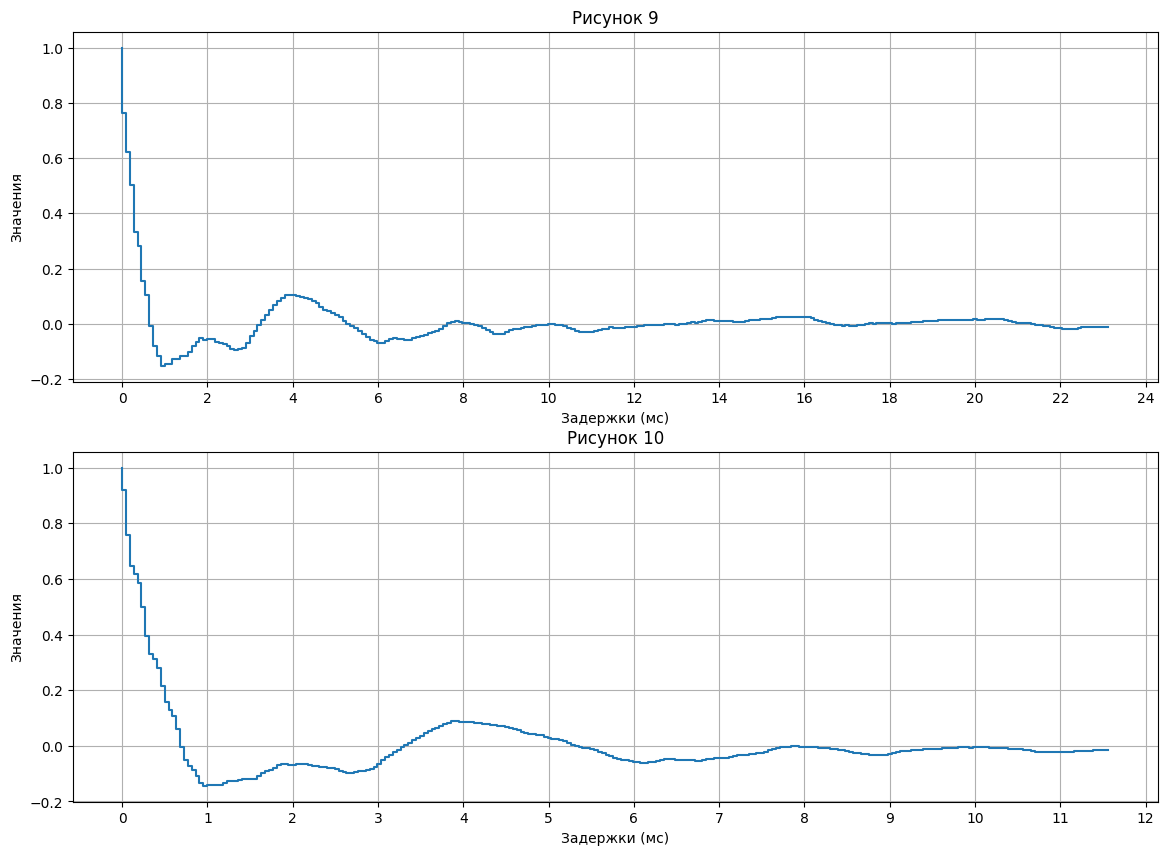

In [ ]:
# Строим шкалы
frame_len = 512
lag = frame_len // 2
t1 = Timeline(lag, sr_11sp_fm1)
t2 = Timeline(lag, sr_11sp_fm1 * 2)

# Строим средние оценку АКФ сигналов
win = signal.windows.boxcar(frame_len)  # Окно прямоугольное
acf_data_11sp_fm1 = AAF(data=data_11sp_fm1, frame_len=frame_len, win=win, lag=lag)
acf_data_11sp_fm2 = AAF(data=data_11sp_fm2, frame_len=frame_len, win=win, lag=lag)

# Визуализация
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

ax[0].step(t1, acf_data_11sp_fm1)
ax[0].set_title("Рисунок 9")
ax[0].set_xlabel("Задержки (мс)")
ax[0].set_ylabel("Значения")
ax[0].locator_params(axis="x", nbins=16)
ax[0].grid(True)

ax[1].step(t2, acf_data_11sp_fm2)
ax[1].set_title("Рисунок 10")
ax[1].set_xlabel("Задержки (мс)")
ax[1].set_ylabel("Значения")
ax[1].locator_params(axis="x", nbins=16)
ax[1].grid(True)

plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

При увеличение частоты дискретизации количесто отображаемых примеро на графике становится больше (график снизу более ребристый). Вместе с тем, при большей частоте дискретизации график имеет меньше одиночных пиков

</div>